<a href="https://colab.research.google.com/github/cchen744/lst-htindex-compare/blob/main/lst-analysis/LST_analysis_JJA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LST Analysis: Miami vs Phoenix (JJA 2020-2024)

Comparing Land Surface Temperature patterns across humid (Miami) and arid (Phoenix) urban environments using MODIS MOD11A1 satellite data.

In [6]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
import libpysal as ps
from esda import Moran
import os

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize(project='extremeweatheruhi')

print("✓ GEE initialized")

✓ GEE initialized


In [7]:
!git clone https://github.com/cchen744/lst-htindex-compare.git -q

In [8]:
import sys
sys.path.insert(0, './lst-htindex-compare/lst-analysis')
from lst_pipeline import create_config, JJALSTPipeline
print("✓ Pipeline imported")

✓ Pipeline imported


In [9]:
os.makedirs('./outputs', exist_ok=True)

print("\nRunning Miami analysis...")
config_miami = create_config('Miami', start_year=2020, end_year=2024, output_dir='./outputs')
miami_pipeline = JJALSTPipeline(config_miami)
miami_results = miami_pipeline.run(export_geotiff=False)
miami_stats = miami_results['statistics']
print(miami_stats)


Running Miami analysis...
GEE initialization note: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

JJA LST Analysis Pipeline: Miami
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 4: Exporting statistics...
  → Statistics: outputs/Miami/Miami_JJA_statistics.csv
  → Output dir: outputs/Miami

✓ Pipeline complete!

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    35.590097          35.71    2.849616       30.63   
1  2021    JJA    35.532939          35.69    2.633969       30.11   
2  2022    JJA    37.039030          37.27    2.666318       30.11   
3  2023    JJA    34.788045          34.72    2.653050       30.13   
4  2024    JJA    34.720317          35.13    2.587195       29.47   

   max_temp_c  temp_range_c  
0       42.47         1

In [10]:
print("\nRunning Phoenix analysis...")
config_phoenix = create_config('Phoenix', start_year=2020, end_year=2024, output_dir='./outputs')
phoenix_pipeline = JJALSTPipeline(config_phoenix)
phoenix_results = phoenix_pipeline.run(export_geotiff=False)
phoenix_stats = phoenix_results['statistics']
print(phoenix_stats)


Running Phoenix analysis...
GEE initialization note: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

JJA LST Analysis Pipeline: Phoenix
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 4: Exporting statistics...
  → Statistics: outputs/Phoenix/Phoenix_JJA_statistics.csv
  → Output dir: outputs/Phoenix

✓ Pipeline complete!

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    51.040624          51.47    1.662779       47.69   
1  2021    JJA    50.434480          50.45    1.221978       47.56   
2  2022    JJA    50.245517          50.60    1.000401       47.63   
3  2023    JJA    49.130374          49.52    1.531402       45.10   
4  2024    JJA    48.466165          49.09    0.981995       46.67   

   max_temp_c  temp_range_c  
0       53.56

In [11]:
miami_stats['city'] = 'Miami'
phoenix_stats['city'] = 'Phoenix'
combined = pd.concat([miami_stats, phoenix_stats], ignore_index=True)
print(combined)

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    35.590097          35.71    2.849616       30.63   
1  2021    JJA    35.532939          35.69    2.633969       30.11   
2  2022    JJA    37.039030          37.27    2.666318       30.11   
3  2023    JJA    34.788045          34.72    2.653050       30.13   
4  2024    JJA    34.720317          35.13    2.587195       29.47   
5  2020    JJA    51.040624          51.47    1.662779       47.69   
6  2021    JJA    50.434480          50.45    1.221978       47.56   
7  2022    JJA    50.245517          50.60    1.000401       47.63   
8  2023    JJA    49.130374          49.52    1.531402       45.10   
9  2024    JJA    48.466165          49.09    0.981995       46.67   

   max_temp_c  temp_range_c     city  
0       42.47         11.84    Miami  
1       40.68         10.57    Miami  
2       42.06         11.95    Miami  
3       43.87         13.74    Miami  
4       39.15          9.68    Mia

## Moran's I

In [12]:
def compute_morans_i(image, region, city_name, num_samples=150):
    bounds = region.bounds().getInfo()
    coords_list = bounds['coordinates'][0]
    lons = [c[0] for c in coords_list]
    lats = [c[1] for c in coords_list]

    grid_size = int(np.sqrt(num_samples))
    lons_grid = np.linspace(min(lons), max(lons), grid_size)
    lats_grid = np.linspace(min(lats), max(lats), grid_size)

    points = [ee.Geometry.Point([lon, lat]) for lon in lons_grid for lat in lats_grid]
    sampled = image.sample(region=ee.FeatureCollection(points), scale=1000)
    values = sampled.aggregate_array(config_miami.lst_band).getInfo()

    temps_c = np.array([v * 0.02 - 273.15 for v in values if v])
    coords = np.array([[lons_grid[i % grid_size], lats_grid[i // grid_size]]
                       for i in range(len(points))])[:len(temps_c)]

    weights = ps.weights.KNN.from_array(coords, k=5)
    mi = Moran(temps_c, weights)
    return {'city': city_name, 'morans_i': mi.I, 'p_value': mi.p_norm}

print("Computing Moran's I...")
miami_jja_mean = ee.ImageCollection(list(miami_results['jja_data_gee'].values())).mean()
phoenix_jja_mean = ee.ImageCollection(list(phoenix_results['jja_data_gee'].values())).mean()

miami_mi = compute_morans_i(miami_jja_mean, config_miami.create_geom(), 'Miami')
phoenix_mi = compute_morans_i(phoenix_jja_mean, config_phoenix.create_geom(), 'Phoenix')
morans_df = pd.DataFrame([miami_mi, phoenix_mi])
print(morans_df)

Computing Moran's I...
      city  morans_i   p_value
0    Miami -0.003381  0.759850
1  Phoenix -0.154470  0.887473


## Hotspot

In [13]:
def get_hotspot_pct(image, region):
    threshold = image.reduceRegion(ee.Reducer.percentile([75]), region, scale=1000).getInfo()
    threshold_val = list(threshold.values())[0]
    hotspot_mask = image.gte(threshold_val)
    total_pixels = image.reduceRegion(ee.Reducer.count(), region, 1000).getInfo()
    hotspot_pixels = hotspot_mask.reduceRegion(ee.Reducer.sum(), region, 1000).getInfo()
    count = list(total_pixels.values())[0]
    hotspots = list(hotspot_pixels.values())[0]
    return (hotspots / count * 100) if count > 0 else 0

miami_hotspot = get_hotspot_pct(miami_jja_mean, config_miami.create_geom())
phoenix_hotspot = get_hotspot_pct(phoenix_jja_mean, config_phoenix.create_geom())
print(f"Miami: {miami_hotspot:.2f}%, Phoenix: {phoenix_hotspot:.2f}%")

Miami: 25.61%, Phoenix: 36.33%


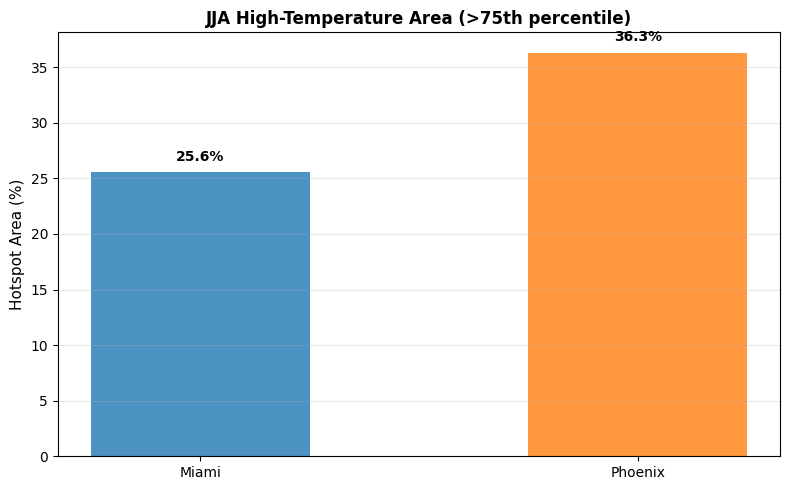

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
cities = ['Miami', 'Phoenix']
hotspots = [miami_hotspot, phoenix_hotspot]
bars = ax.bar(cities, hotspots, color=['#1f77b4', '#ff7f0e'], alpha=0.8, width=0.5)
ax.set_ylabel('Hotspot Area (%)', fontsize=11)
ax.set_title('JJA High-Temperature Area (>75th percentile)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, hotspots):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/hotspot_jja_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Spatial Variability

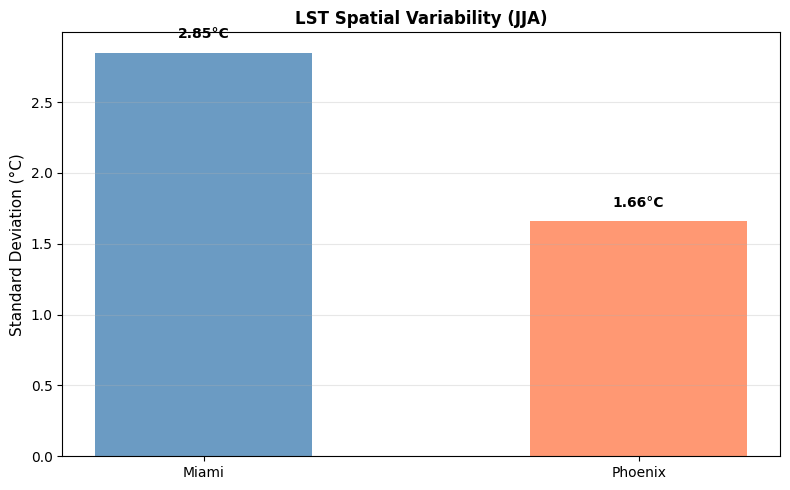

In [15]:
miami_std = miami_stats['std_temp_c'].values[0]
phoenix_std = phoenix_stats['std_temp_c'].values[0]
fig, ax = plt.subplots(figsize=(8, 5))
cities = ['Miami', 'Phoenix']
stds = [miami_std, phoenix_std]
bars = ax.bar(cities, stds, color=['steelblue', 'coral'], alpha=0.8, width=0.5)
ax.set_ylabel('Standard Deviation (°C)', fontsize=11)
ax.set_title('LST Spatial Variability (JJA)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, stds):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/temperature_variability.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings and Interpretation

In [16]:
miami_mean = miami_stats['mean_temp_c'].mean()
phoenix_mean = phoenix_stats['mean_temp_c'].mean()
temp_diff = phoenix_mean - miami_mean
miami_yearly = miami_stats.groupby('year')['mean_temp_c'].mean()
phoenix_yearly = phoenix_stats.groupby('year')['mean_temp_c'].mean()
miami_trend = np.polyfit(miami_yearly.index, miami_yearly.values, 1)[0]
phoenix_trend = np.polyfit(phoenix_yearly.index, phoenix_yearly.values, 1)[0]

print("\n" + "="*70)
print("KEY FINDINGS: LST Comparison Miami vs Phoenix (JJA 2020-2024)")
print("="*70)
print(f"\n1. ABSOLUTE TEMPERATURE (JJA):")
print(f"   Miami: {miami_mean:.2f}°C, Phoenix: {phoenix_mean:.2f}°C (Δ={temp_diff:+.2f}°C)")
print(f"\n2. WARMING TREND: Miami {miami_trend:+.4f}°C/year, Phoenix {phoenix_trend:+.4f}°C/year")
print(f"\n3. SPATIAL VARIABILITY: Miami {miami_std:.2f}°C, Phoenix {phoenix_std:.2f}°C")
print(f"\n4. SPATIAL AUTOCORRELATION (Moran's I): Miami {morans_df.loc[0, 'morans_i']:.3f}, Phoenix {morans_df.loc[1, 'morans_i']:.3f}")
print(f"\n5. HIGH-TEMPERATURE AREAS: Miami {miami_hotspot:.1f}%, Phoenix {phoenix_hotspot:.1f}%")
print("\n" + "="*70)


KEY FINDINGS: LST Comparison Miami vs Phoenix (JJA 2020-2024)

1. ABSOLUTE TEMPERATURE (JJA):
   Miami: 35.53°C, Phoenix: 49.86°C (Δ=+14.33°C)

2. WARMING TREND: Miami -0.2484°C/year, Phoenix -0.6453°C/year

3. SPATIAL VARIABILITY: Miami 2.85°C, Phoenix 1.66°C

4. SPATIAL AUTOCORRELATION (Moran's I): Miami -0.003, Phoenix -0.154

5. HIGH-TEMPERATURE AREAS: Miami 25.6%, Phoenix 36.3%



In [17]:
combined_final = pd.concat([miami_stats.assign(city='Miami'), phoenix_stats.assign(city='Phoenix')], ignore_index=True)
combined_final.to_csv('./outputs/LST_combined_statistics.csv', index=False)

summary = f"""LST ANALYSIS SUMMARY: Miami vs Phoenix (JJA 2020-2024)
{'='*60}
Temperature: Miami {miami_mean:.2f}°C, Phoenix {phoenix_mean:.2f}°C (Δ{temp_diff:+.2f}°C)
Trend: Miami {miami_trend:+.4f}°C/year, Phoenix {phoenix_trend:+.4f}°C/year
Variability: Miami {miami_std:.2f}°C, Phoenix {phoenix_std:.2f}°C
Moran's I: Miami {morans_df.loc[0, 'morans_i']:.3f}, Phoenix {morans_df.loc[1, 'morans_i']:.3f}
Hotspots: Miami {miami_hotspot:.1f}%, Phoenix {phoenix_hotspot:.1f}%
Data: MODIS/061/MOD11A1, {pd.Timestamp.now().strftime('%Y-%m-%d')}
"""

with open('./outputs/LST_analysis_summary.txt', 'w') as f:
    f.write(summary)

print("✓ Exported: LST_combined_statistics.csv, LST_analysis_summary.txt")
print(summary)

✓ Exported: LST_combined_statistics.csv, LST_analysis_summary.txt
LST ANALYSIS SUMMARY: Miami vs Phoenix (JJA 2020-2024)
Temperature: Miami 35.53°C, Phoenix 49.86°C (Δ+14.33°C)
Trend: Miami -0.2484°C/year, Phoenix -0.6453°C/year
Variability: Miami 2.85°C, Phoenix 1.66°C
Moran's I: Miami -0.003, Phoenix -0.154
Hotspots: Miami 25.6%, Phoenix 36.3%
Data: MODIS/061/MOD11A1, 2026-04-24

